# Microproyecto 2 — Clasificación de textos según lista ODS de la ONU

Germán Pinzón (201415974)

Diego Klinger (202524323)

### Nota - Uso de IA:
Utilizamos asistencia de la IA para lo siguiente:

## 1. Librerías:

In [5]:
import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder, Normalizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import sklearn
import nltk

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [6]:
print('Versión de librerías usadas en este notebook:')
print(f'numpy: {np.__version__}')
print(f'pandas: {pd.__version__}')
print(f'matplotlib: {plt.matplotlib.__version__}')
print(f'seaborn: {sns.__version__}')
print(f'sklearn: {sklearn.__version__}')
print(f'nltk: {nltk.__version__}')

Versión de librerías usadas en este notebook:
numpy: 2.0.2
pandas: 2.2.2
matplotlib: 3.10.0
seaborn: 0.13.2
sklearn: 1.6.1
nltk: 3.9.1


## 2. Carga de datos a modelar y EDA:

In [7]:
df = pd.read_excel('/content/Train_textosODS.xlsx')
print(f'Tamaño del dataset: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')
print()
print('Tipos de datos:')
print(df.dtypes)
print()
print('Valores nulos:')
print(df.isnull().sum())
df.head()

Tamaño del dataset: (9656, 2)
Columnas: ['textos', 'ODS']

Tipos de datos:
textos    object
ODS        int64
dtype: object

Valores nulos:
textos    0
ODS       0
dtype: int64


,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13
3,Con el Congreso firmemente en control de la ju...,16
4,"Luego, dos secciones finales analizan las impl...",5


In [8]:
# Extraídos de https://sdgs.un.org/es/goals:

ods_list = {
    1: 'Fin de la pobreza',
    2: 'Hambre cero',
    3: 'Salud y bienestar',
    4: 'Educación de calidad',
    5: 'Igualdad de género',
    6: 'Agua limpia y saneamiento',
    7: 'Energía asequible y no contaminante',
    8: 'Trabajo decente y crecimiento económico',
    9: 'Industria, innovación e infraestructura',
    10: 'Reducción de las desigualdades',
    11: 'Ciudades y comunidades sostenibles',
    12: 'Producción y consumo responsables',
    13: 'Acción por el clima',
    14: 'Vida submarina',
    15: 'Vida de ecosistemas terrestres',
    16: 'Paz, justicia e instituciones sólidas',
    17: 'Alianzas para lograr los objetivos',
}

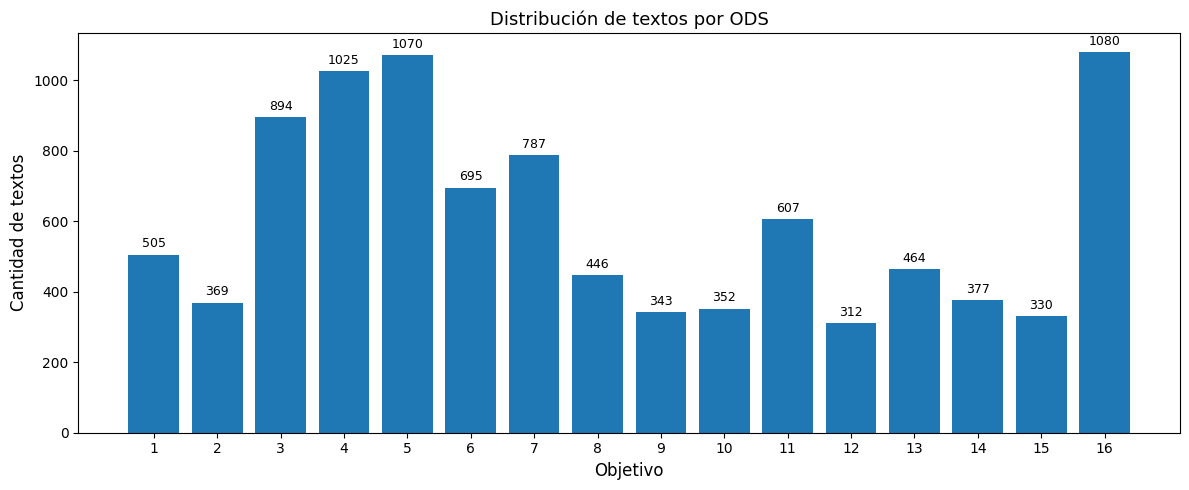

In [9]:
#plt.style.use('seaborn-v0_8-whitegrid')
conteo_dist = df['ODS'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(conteo_dist.index, conteo_dist.values)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel('Objetivo', fontsize=12)
ax.set_ylabel('Cantidad de textos', fontsize=12)
ax.set_title('Distribución de textos por ODS', fontsize=13)
ax.set_xticks(conteo_dist.index)
plt.tight_layout()
plt.show()

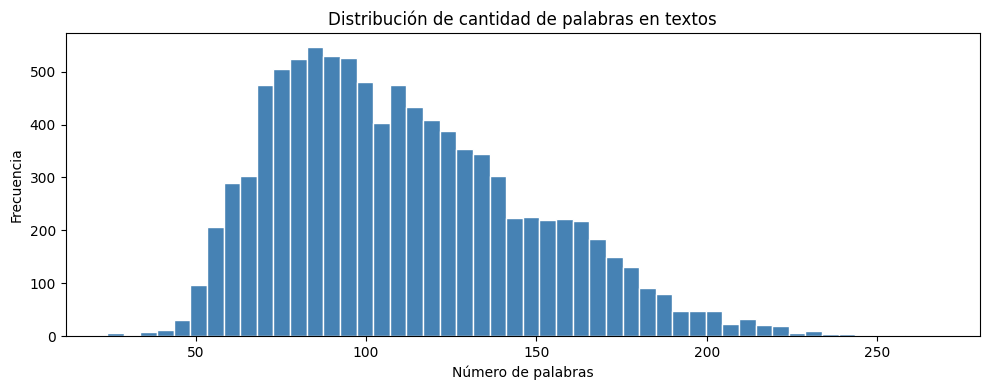

Cantidad promedio de palabras: 111 palabras
Mínima: 24 | Máxima: 268


In [10]:
df['conteo_palabras'] = df['textos'].str.split().str.len()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['conteo_palabras'], bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('Número de palabras')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de cantidad de palabras en textos')
plt.tight_layout()
plt.show()

print(f"Cantidad promedio de palabras: {df['conteo_palabras'].mean():.0f} palabras")
print(f"Mínima: {df['conteo_palabras'].min()} | Máxima: {df['conteo_palabras'].max()}")

## 3. Preprocesamiento de insumos para modelado

In [11]:
from tqdm.notebook import tqdm
tqdm.pandas(desc="Processing Rows")

def limpiar_texto(texto: str) -> str:
    """Limpia y normaliza un texto en español."""
    # Minúsculas
    texto = texto.lower()
    # Elimina chars no alfabéticos (conserva letras con tilde y ñ)
    texto = re.sub(r'[^a-záéíóúüñ\s]', ' ', texto)
    # Tokeniza por palabra
    tokens = texto.split()
    # Filtra stopwords y palabras muy cortas
    tokens = [t for t in tokens if t not in set(stopwords.words('spanish')) and len(t) > 2]
    return ' '.join(tokens)

# Aplicar preprocesamiento
df['texto_limpio'] = df['textos'].progress_apply(limpiar_texto)

Processing Rows:   0%|          | 0/9656 [00:00<?, ?it/s]

##4. Dataset split para entrenamiento, validación y prueba:

In [12]:
X = df['texto_limpio']
y = df['ODS']

# 80% train 20% test. Se usa stratify para conservar la proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Registros para conjunto train: {len(X_train)} textos')
print(f'Registros para conjunto test: {len(X_test)} textos')

Registros para conjunto train: 7724 textos
Registros para conjunto test: 1932 textos


## 5. Pipeline: TF-IDF + Truncated SVD:

In [13]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer( # Vectores de relevancia de términos en documentos
        analyzer='word',
        ngram_range=(1, 2), # Matriz de tf-idf para unigramas y bigramas
        max_features=50000, # vocabulario máximo (Tiempo razonable para entrenar en 2 hilos de CPU)
        sublinear_tf=True, # escala log en tf-idf para disminuir impacto de palabras muy repetidas
        min_df=2, # ignorar términos que aparecen en menos de 2 documentos
    )),
    ('svd', TruncatedSVD(random_state=42)), # Single Value Decomposition para reducción dimensionalidad a conceptos
    ('normalizer', Normalizer()), # Normaliza vectores en espacio semántico latente
    ('clf', LinearSVC(max_iter=2000, random_state=42)), # SVM con kernel linear
])

pipeline

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('svd', TruncatedSVD(random_state=42)),
                ('normalizer', Normalizer()),
                ('clf', LinearSVC(max_iter=2000, random_state=42))])

## 6. Búsqueda de hiperparámetros:

In [14]:
param_grid = {
    'svd__n_components': [100, 200, 300], # Cantidad de componentes en el espacio latente
    'clf__C': [0.1, 1.0, 5.0], # Valores de regularización para el clasificador SVM
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # Mantiene la proporción de clases en cada fold

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1_macro', # calcula f1 tratando a cada clase por igual sin importar peso
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print(f'\nMejores parámetros encontrados: {grid_search.best_params_}')
print(f'Mejor F1 (macro): {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 9 candidates, totalling 45 fits

Mejores parámetros encontrados: {'clf__C': 1.0, 'svd__n_components': 300}
Mejor F1 (macro): 0.8469


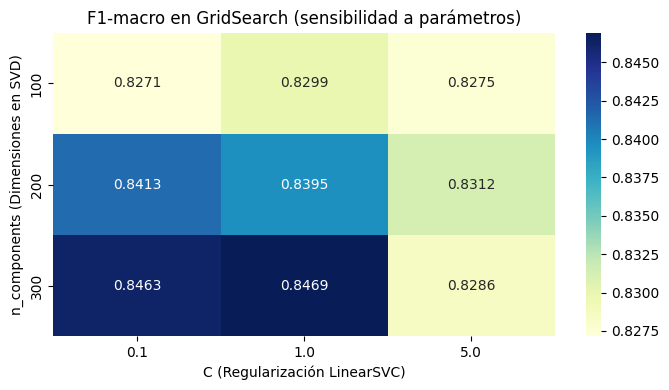

In [15]:
results = pd.DataFrame(grid_search.cv_results_)
pivot = results.pivot_table(
    index='param_svd__n_components',
    columns='param_clf__C',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax)
ax.set_title('F1-macro en GridSearch (sensibilidad a parámetros)')
ax.set_xlabel('C (Regularización LinearSVC)')
ax.set_ylabel('n_components (Dimensiones en SVD)')
plt.tight_layout()
plt.show()

## 7. Evaluación sobre conjunto test:

In [16]:
mejor_modelo = grid_search.best_estimator_
y_pred = mejor_modelo.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy en conjunto test: {acc:.4f} ({acc*100:.2f}%)')
print()
print(classification_report(y_test, y_pred, digits=4))

Accuracy en conjunto test: 0.8778 (87.78%)

              precision    recall  f1-score   support

           1     0.8438    0.8020    0.8223       101
           2     0.7927    0.8784    0.8333        74
           3     0.9330    0.9330    0.9330       179
           4     0.9476    0.9707    0.9590       205
           5     0.9273    0.9533    0.9401       214
           6     0.9291    0.9424    0.9357       139
           7     0.8882    0.9051    0.8966       158
           8     0.5862    0.5730    0.5795        89
           9     0.7966    0.6812    0.7344        69
          10     0.7458    0.6286    0.6822        70
          11     0.8130    0.8197    0.8163       122
          12     0.8644    0.8226    0.8430        62
          13     0.8119    0.8817    0.8454        93
          14     0.9275    0.8533    0.8889        75
          15     0.8939    0.8939    0.8939        66
          16     0.9455    0.9630    0.9541       216

    accuracy                        

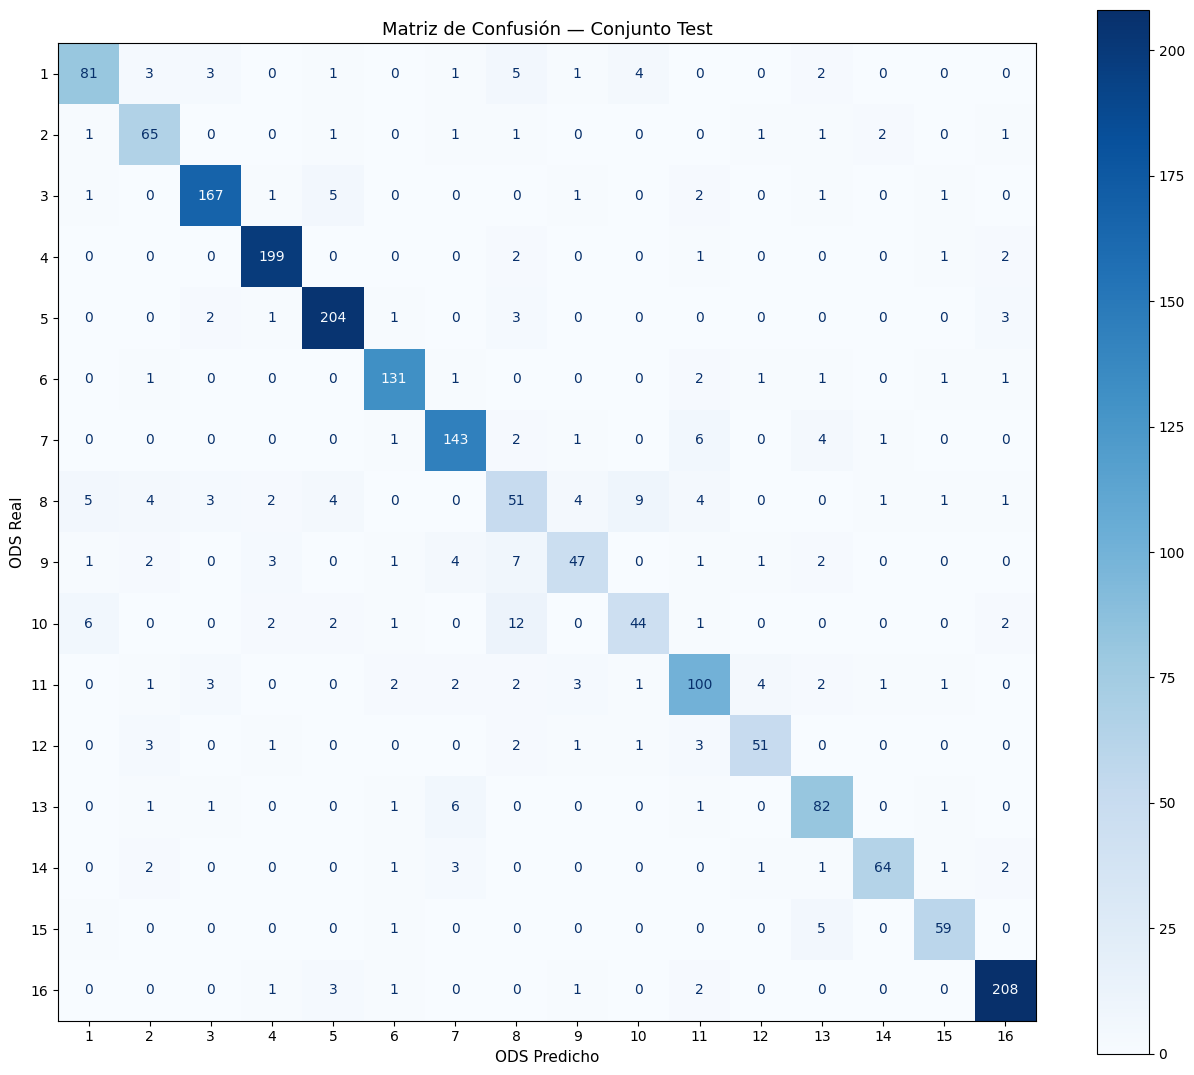

In [17]:
cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))

fig, ax = plt.subplots(figsize=(13, 11))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='d')
ax.set_title('Matriz de Confusión — Conjunto Test', fontsize=13)
ax.set_xlabel('ODS Predicho', fontsize=11)
ax.set_ylabel('ODS Real', fontsize=11)
plt.tight_layout()
plt.show()

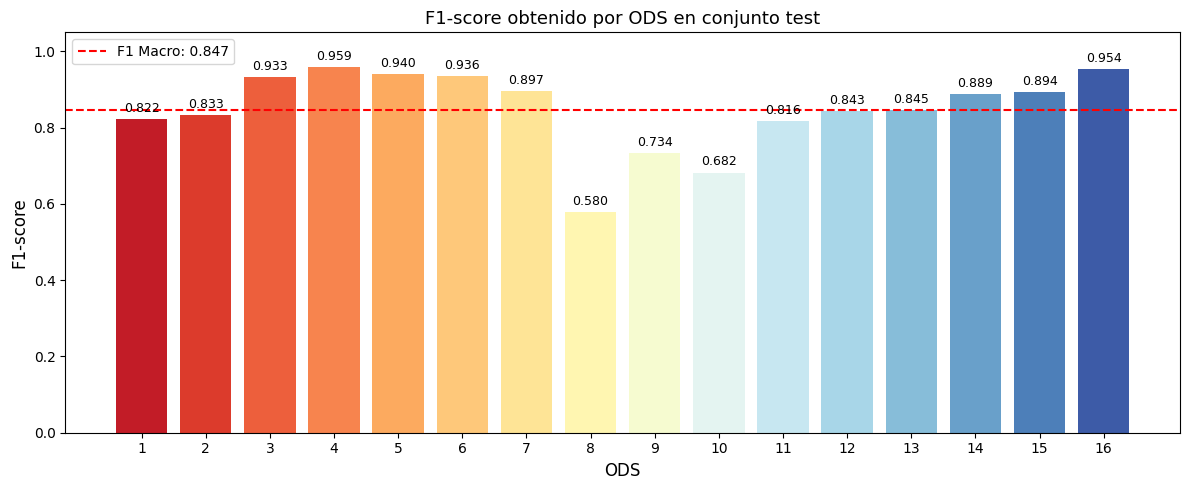

In [18]:
from sklearn.metrics import f1_score
clases = sorted(y.unique())
f1_por_clase = f1_score(y_test, y_pred, labels=clases, average=None)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(clases, f1_por_clase, color=sns.color_palette('RdYlBu', len(clases)))
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_xlabel('ODS', fontsize=12)
ax.set_ylabel('F1-score', fontsize=12)
ax.set_title('F1-score obtenido por ODS en conjunto test', fontsize=13)
ax.set_xticks(clases)
ax.set_ylim(0, 1.05)
ax.axhline(y=f1_por_clase.mean(), color='red', linestyle='--', label=f'F1 Macro: {f1_por_clase.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
def predecir_ods(texto: str, modelo) -> None:
    """Predice el ODS para un texto libre."""
    texto_preproc = limpiar_texto(texto)
    ods = modelo.predict([texto_preproc])[0]
    print(f'ODS predicho: {ods}. {ods_list.get(ods, "Desconocido")}')

In [20]:
test_texts = ["Las energías renovables como la solar y eólica son clave para reducir las emisiones de CO2 y combatir el cambio climático global",
              "El acceso al agua potable es fundamental para la salud de las comunidades rurales. ",
              "Se deben implementar sistemas de saneamiento básico y tratamiento de aguas residuales.",
              "Las energías renovables como la solar y eólica son clave para reducir las emisiones de CO2 y combatir el cambio climático global.",
              "La brecha salarial entre hombres y mujeres sigue siendo una barrera para la igualdad de género en el mercado laboral de América Latina.",
              "Los arrecifes de coral se están blanqueando por el aumento de la temperatura oceánica, poniendo en riesgo la biodiversidad marina y los ecosistemas costeros."
             ]

for text in test_texts:
  print(f'Texto: {text}')
  prediccion = predecir_ods(text, mejor_modelo)
  print(prediccion)
  print('--')

Texto: Las energías renovables como la solar y eólica son clave para reducir las emisiones de CO2 y combatir el cambio climático global
ODS predicho: 7. Energía asequible y no contaminante
None
--
Texto: El acceso al agua potable es fundamental para la salud de las comunidades rurales. 
ODS predicho: 6. Agua limpia y saneamiento
None
--
Texto: Se deben implementar sistemas de saneamiento básico y tratamiento de aguas residuales.
ODS predicho: 6. Agua limpia y saneamiento
None
--
Texto: Las energías renovables como la solar y eólica son clave para reducir las emisiones de CO2 y combatir el cambio climático global.
ODS predicho: 7. Energía asequible y no contaminante
None
--
Texto: La brecha salarial entre hombres y mujeres sigue siendo una barrera para la igualdad de género en el mercado laboral de América Latina.
ODS predicho: 5. Igualdad de género
None
--
Texto: Los arrecifes de coral se están blanqueando por el aumento de la temperatura oceánica, poniendo en riesgo la biodiversidad m

## 8. Conclusiones

## 9. App Streamlit:

### 9.1 Persistencia del modelo

In [24]:
import joblib
import os

# Guardar modelo y label encoder
joblib.dump(mejor_modelo, 'modelo_clasificador_ODS.pkl')

# Descargar desde Colab a tu PC
from google.colab import files
files.download('modelo_clasificador_ODS.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>